### Проверка корреляции лагов

Описание вводной информации:
1. Для анализа предоставлен обезличенный временной ряд,
2. Необходимо определить наилучший временной лаг для каждого left,
3. Свойство процесса: left1 - left2 = right.

In [ ]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean
from statsmodels.robust.scale import mad
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.fft import fft, fftfreq
import scipy.stats as st
from scipy.stats import linregress

In [2]:
# загрузка файла
df = pd.read_csv('C:/Users/FokinDV/Desktop/Data Science/Задача на 01.09.2025/dataset1.csv')

In [3]:
# обзор основной информации датасета, ищем пропуски, дубликаты
display(df.columns)
display(df.info())
display(df.describe())
display(df.head(10))
display(df.tail(10))
display(df.isna().sum())
display(df.isnull().sum())
display(df.duplicated().sum())

Index(['Unnamed: 0', 'datetime', 'leftname1', 'leftname2', 'rightname'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123407 entries, 0 to 123406
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  123407 non-null  int64  
 1   datetime    123407 non-null  object 
 2   leftname1   123407 non-null  float64
 3   leftname2   123407 non-null  float64
 4   rightname   123407 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.7+ MB


None

,Unnamed: 0,leftname1,leftname2,rightname
count,123407.000000,123407.000000,123407.000000,123407.000000
mean,61703.000000,19.490608,0.370028,10.962428
std,35624.676672,13.139819,2.114646,10.786160
min,0.000000,0.000000,-1.130000,0.000000
25%,30851.500000,14.400000,0.000000,0.000000
50%,61703.000000,18.240000,0.000000,14.092344
75%,92554.500000,25.920000,0.000000,19.672686
max,123406.000000,246.000000,246.000000,64.631526


,Unnamed: 0,datetime,leftname1,leftname2,rightname
0,0,2025-06-01 20:01:00,0.0,0.0,0.000000
1,1,2025-06-01 20:02:00,0.0,0.0,0.000000
2,2,2025-06-01 20:03:00,0.0,0.0,0.000000
3,3,2025-06-01 20:04:00,0.0,0.0,0.000000
4,4,2025-06-01 20:05:00,0.0,0.0,0.000000
5,5,2025-06-01 20:06:00,0.0,0.0,15.038201
6,6,2025-06-01 20:07:00,0.0,0.0,14.928355
7,7,2025-06-01 20:08:00,0.0,0.0,15.595362
8,8,2025-06-01 20:09:00,0.0,0.0,0.000000
9,9,2025-06-01 20:10:00,0.0,0.0,14.972913


,Unnamed: 0,datetime,leftname1,leftname2,rightname
123397,123397,2025-08-26 12:38:00,18.08,0.00,18.234701
123398,123398,2025-08-26 12:39:00,18.24,0.00,0.000000
123399,123399,2025-08-26 12:40:00,16.32,0.00,17.922020
123400,123400,2025-08-26 12:41:00,17.12,0.00,18.229893
123401,123401,2025-08-26 12:42:00,17.44,-0.13,16.309643
123402,123402,2025-08-26 12:43:00,16.16,0.00,16.085598
123403,123403,2025-08-26 12:44:00,33.12,0.00,16.834370
123404,123404,2025-08-26 12:45:00,16.64,0.00,17.281729
123405,123405,2025-08-26 12:46:00,18.40,0.00,16.779144
123406,123406,2025-08-26 12:47:00,17.92,-0.13,0.000000


Unnamed: 0    0
datetime      0
leftname1     0
leftname2     0
rightname     0
dtype: int64

Unnamed: 0    0
datetime      0
leftname1     0
leftname2     0
rightname     0
dtype: int64

0

In [4]:
# конвертируем столбец даты/времени в соответствующий тип данных 
df['datetime'] = df['datetime'].astype('datetime64[ns]')
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123407 entries, 0 to 123406
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Unnamed: 0  123407 non-null  int64         
 1   datetime    123407 non-null  datetime64[ns]
 2   leftname1   123407 non-null  float64       
 3   leftname2   123407 non-null  float64       
 4   rightname   123407 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 4.7 MB


None

In [5]:
# устанавливаем индекс
df = df.set_index('datetime')
display(df.head(10))

,Unnamed: 0,leftname1,leftname2,rightname
datetime,,,,
2025-06-01 20:01:00,0,0.0,0.0,0.000000
2025-06-01 20:02:00,1,0.0,0.0,0.000000
2025-06-01 20:03:00,2,0.0,0.0,0.000000
2025-06-01 20:04:00,3,0.0,0.0,0.000000
2025-06-01 20:05:00,4,0.0,0.0,0.000000
2025-06-01 20:06:00,5,0.0,0.0,15.038201
2025-06-01 20:07:00,6,0.0,0.0,14.928355
2025-06-01 20:08:00,7,0.0,0.0,15.595362
2025-06-01 20:09:00,8,0.0,0.0,0.000000


In [6]:
# удаляем ненужный столбец
df = df.drop('Unnamed: 0', axis=1)
display(df.head(10))
display(df.info())

,leftname1,leftname2,rightname
datetime,,,
2025-06-01 20:01:00,0.0,0.0,0.000000
2025-06-01 20:02:00,0.0,0.0,0.000000
2025-06-01 20:03:00,0.0,0.0,0.000000
2025-06-01 20:04:00,0.0,0.0,0.000000
2025-06-01 20:05:00,0.0,0.0,0.000000
2025-06-01 20:06:00,0.0,0.0,15.038201
2025-06-01 20:07:00,0.0,0.0,14.928355
2025-06-01 20:08:00,0.0,0.0,15.595362
2025-06-01 20:09:00,0.0,0.0,0.000000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 123407 entries, 2025-06-01 20:01:00 to 2025-08-26 12:47:00
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   leftname1  123407 non-null  float64
 1   leftname2  123407 non-null  float64
 2   rightname  123407 non-null  float64
dtypes: float64(3)
memory usage: 3.8 MB


None

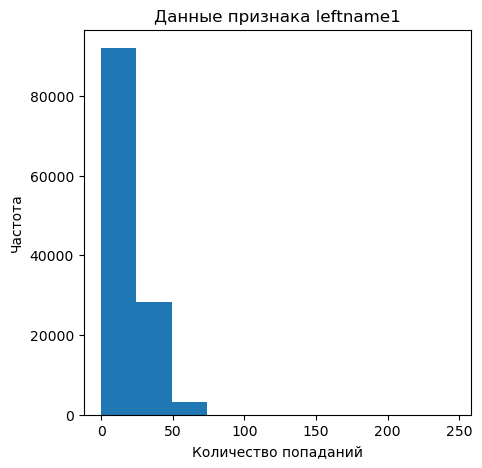

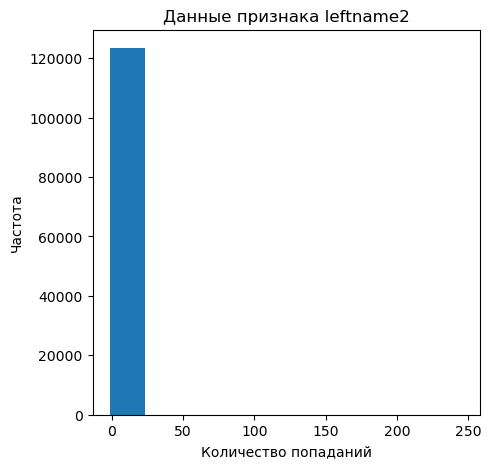

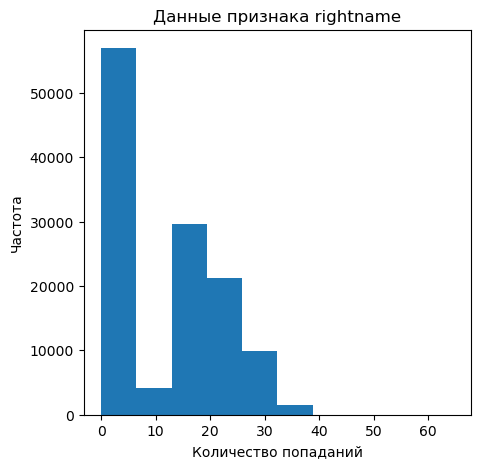

In [7]:
# смотрим и анализируем гисторграммы по признакам
ax = df['leftname1'].plot.hist(figsize=(5,5))
ax.set_xlabel('Количество попаданий')
ax.set_ylabel('Частота')
plt.title('Данные признака leftname1')
plt.show()

ax = df['leftname2'].plot.hist(figsize=(5,5))
ax.set_xlabel('Количество попаданий')
ax.set_ylabel('Частота')
plt.title('Данные признака leftname2')
plt.show()

ax = df['rightname'].plot.hist(figsize=(5,5))
ax.set_xlabel('Количество попаданий')
ax.set_ylabel('Частота')
plt.title('Данные признака rightname')
plt.show()

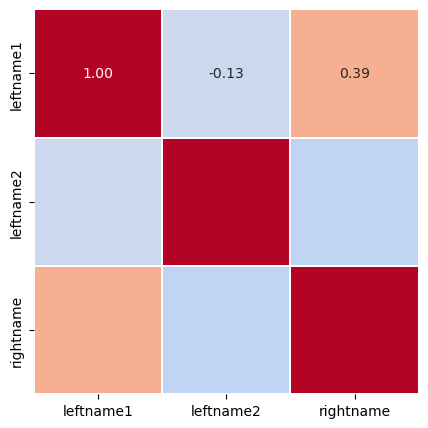

,leftname1,leftname2,rightname
leftname1,1.000000,-0.128231,0.389510
leftname2,-0.128231,1.000000,-0.191707
rightname,0.389510,-0.191707,1.000000


In [8]:
# строим матрицу корреляций по признакам(корреляция с нулевым лагом(данные не смещены))
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, square=True, cbar=False, linewidth=0.1, cmap='coolwarm', fmt='.2f')
plt.show()
# значения корреляций с нулевым лагом
display(df.corr())

,leftname1,leftname2,rightname,left_result
datetime,,,,
2025-06-01 20:01:00,0.0,0.0,0.000000,0.0
2025-06-01 20:02:00,0.0,0.0,0.000000,0.0
2025-06-01 20:03:00,0.0,0.0,0.000000,0.0
2025-06-01 20:04:00,0.0,0.0,0.000000,0.0
2025-06-01 20:05:00,0.0,0.0,0.000000,0.0
2025-06-01 20:06:00,0.0,0.0,15.038201,0.0
2025-06-01 20:07:00,0.0,0.0,14.928355,0.0
2025-06-01 20:08:00,0.0,0.0,15.595362,0.0
2025-06-01 20:09:00,0.0,0.0,0.000000,0.0


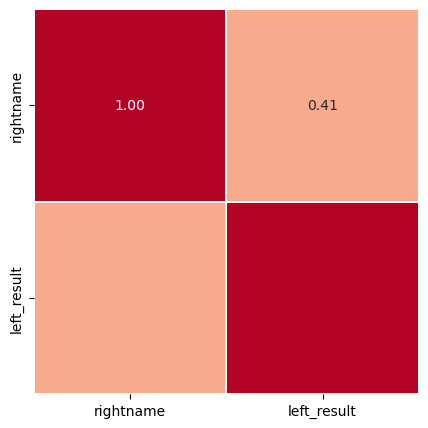

,rightname,left_result
rightname,1.000000,0.406917
left_result,0.406917,1.000000


In [9]:
# расчет корреляции между левой и правой частью при разных сдвигах
# нулевой сдвиг
df_result_corr = df.copy()
df_result_corr['left_result'] = df_result_corr['leftname1'] - df_result_corr['leftname2']
display(df_result_corr.head(10))
# считаем корреляцию при нулевом сдвиге
# построим матрицу, выведем значения корреляций
df_base_lag = df_result_corr.drop(columns=['leftname1', 'leftname2'])
plt.figure(figsize=(5,5))
sns.heatmap(df_base_lag.corr(), vmin=-1, vmax=1, annot=True, square=True, cbar=False, linewidth=0.1, cmap='coolwarm', fmt='.2f')
plt.show()
display(df_base_lag.corr())

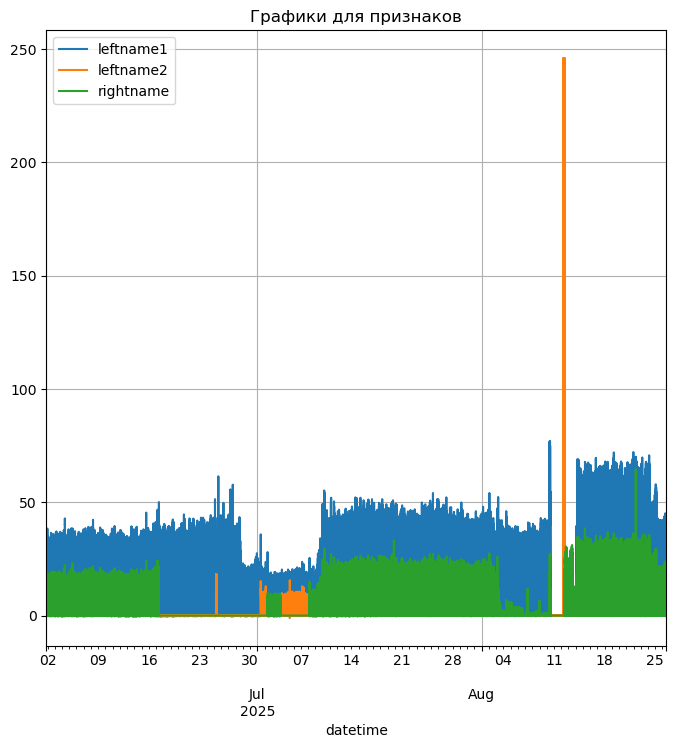

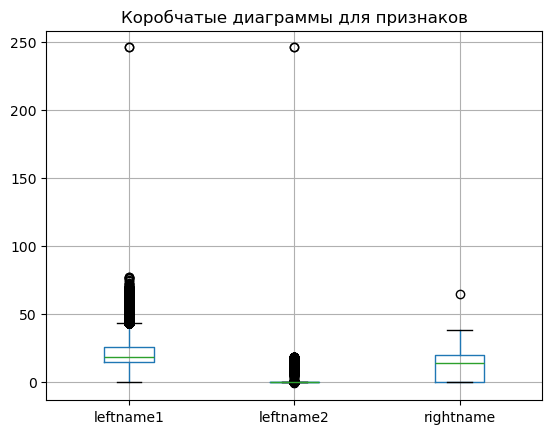

In [10]:
# смотрим и анализируем боксплоты по признакам
df.plot(grid=True, figsize=(8,8))
plt.title('Графики для признаков')
plt.show()
df.boxplot(grid=True)
plt.title('Коробчатые диаграммы для признаков')
plt.show()

In [11]:
# применим SSA для разбиения признаков на основные и остаточные компоненты
class SSA(object):
    __supported_types = (pd.Series, np.ndarray, list)
    def __init__(self, tseries, L, save_mem=True):
        """
        Класс выполняет декомпозицию временного ряда с помощью анализа сингулярного спектра.
        Предполагается, что значения временного ряда записываются через равные промежутки времени.
        
        Принимает параметры:
        - tseries: DataFrame, np.array, list.
            Получение исходного временного ряда.
        - L: int.
            Длина окна. 2 <= L <= N/2, N - длина временного ряда.
            Значение >= 2.
        - save_mem: bool.
            Позволяет экономить память, не сохраняя сгенерированные матрицы. Только для длинных временных рядов со значениями более 1000.
            По умолчанию значение True.
        """
        # Проверка типа входных данных
        if not isinstance(tseries, self.__supported_types):
            raise TypeError('Неподдерживаемый объект, попробуйте формат DataFrame, np.array, list')

        # Проверка значения величины окна L
        self.N = len(tseries)
        if not 2 <= L <= self.N/2:
            raise ValueError('Величина окна должна быть в интервале между (2, N/2).')

        # Задаем значение величины окна
        self.L = L
        self.orig_TS = pd.Series(tseries) # оригинальный временной ряд, как эталон для сравнения реконструкции
        self.K = self.N - self.L + 1 # количество векторов-строк траекторной матрицы

        # Вставляем временной ряд в матрицу траекторий,
        # транспонирование матрицы траекторий, сформированной из временного ряда
        self.X = np.array([self.orig_TS.values[i:L+i] for i in range(0, self.K)]).T

        # Разложение матрицы траекторий на компоненты:
        # - U - матрица левых сингулярных векторов(L*L)(форма базисных функций)
        # - E - диагональная матрица сингулярных значений(L*K)(важность каждой компоненты)
        # - V^T - транспонированная матрица правых сингулярных векторов(K*K)(коэффициенты разложения)
        self.U, self.Sigma, VT = np.linalg.svd(self.X, full_matrices=False) # full_matrices=False - добавил для экономии ресурса
        # Ранг матрицы
        self.d = np.linalg.matrix_rank(self.X)
        # Для экономии памяти вместо L компонентов - d компонентов
        self.TS_comps = np.zeros((self.N, self.d))
        
        # Если не экономим память
        if not save_mem:
            # Построим и сохраним все элементарные матрицы
            self.X_elem = np.array([ self.Sigma[i]*np.outer(self.U[:,i], VT[i,:]) for i in range(self.d) ])

            # Усреднение элементарных матриц по диагонали, сохранение их в виде столбцов массива           
            for i in range(self.d):
                X_rev = self.X_elem[i, ::-1]
                self.TS_comps[:,i] = [X_rev.diagonal(j).mean() for j in range(-X_rev.shape[0]+1, X_rev.shape[1])]
            # Матрица правых сингулярных векторов
            self.V = VT.T
        else:
            # Реконструкция элементарных матриц не сохраняя их
            for i in range(self.d):
                X_elem = self.Sigma[i]*np.outer(self.U[:,i], VT[i,:])
                X_rev = X_elem[::-1]
                self.TS_comps[:,i] = [X_rev.diagonal(j).mean() for j in range(-X_rev.shape[0]+1, X_rev.shape[1])]
            
            self.X_elem = 'Перезапустите функцию с save_mem=False, чтобы сохранить элементарные матрицы.'
            
            # Массив может быть очень большим, не сохраняем его
            self.V = 'Перезапустите функцию с save_mem=False, чтобы сохранить матрицу V.'
        
        # Расчет взвешенной корреляции
        self.calc_wcorr()
            
    def components_to_df(self, n=0):
        """
        Компановка всех компонентов в DataFrame.

        Принимает параметры:
        - n: int.
        Возвращает:
        - DataFrame.
        """
        if n > 0:
            n = min(n, self.d)
        else:
            n = self.d
        
        # Создание списка столбцов с названиями F0, F1, F2, ...
        cols = ['F{}'.format(i) for i in range(n)]
        return pd.DataFrame(self.TS_comps[:, :n], columns=cols, index=self.orig_TS.index)
            
    
    def reconstruct(self, indices):
        """
        Восстановление временного ряда из его элементарных компонентов, используя заданные индексы.

        Принимает параметры:
        - indices: int, list, slice(n,m) object.
        Возвращает:
        - series, DataFrame.
        """
        if isinstance(indices, int): indices = [indices]
        
        ts_vals = self.TS_comps[:,indices].sum(axis=1)
        return pd.Series(ts_vals, index=self.orig_TS.index)
    
    def calc_wcorr(self):
        """
        Вычисляет взвешенную матрицу корреляций временного ряда.
        """
        # Расчет весов для компенсации разного количества диагоналей
        w = np.array(list(np.arange(self.L)+1) + [self.L]*(self.K-self.L-1) + list(np.arange(self.L)+1)[::-1])
        # Взвешенное скалярное произведение
        def w_inner(F_i, F_j):
            return w.dot(F_i*F_j)
        
        # Вычисление взвешенных норм, ||F_i||_w, затем инвертирование.
        F_wnorms = np.array([w_inner(self.TS_comps[:,i], self.TS_comps[:,i]) for i in range(self.d)])
        F_wnorms = F_wnorms**-0.5
        
        # Расчет взвешенной корреляции
        self.Wcorr = np.identity(self.d)
        for i in range(self.d):
            for j in range(i+1,self.d):
                self.Wcorr[i,j] = abs(w_inner(self.TS_comps[:,i], self.TS_comps[:,j]) * F_wnorms[i] * F_wnorms[j])
                self.Wcorr[j,i] = self.Wcorr[i,j]
    
    def plot_wcorr(self, min=None, max=None):
        """
        Строит взвешенную матрицу корреляций для разложенного временного ряда.

        Принимает параметры:
        - min: int.
            Минимальное количество компонентов.
        - max: int.
            Максимальное количество компонентов.            
        Возвращает:
        - графические элементы.
        """
        # Задаем параметры мин и макс для больших матриц корреляций
        if min is None:
            min = 0
        if max is None:
            max = self.d
        # Вычисление взвешенной корреляции
        if self.Wcorr is None:
            self.calc_wcorr()
        # Создание тепловой карты из матрицы
        ax = plt.imshow(self.Wcorr)
        plt.xlabel(r"$\tilde{F}_i$")
        plt.ylabel(r"$\tilde{F}_j$")
        plt.colorbar(ax.colorbar, fraction=0.045)
        ax.colorbar.set_label("$W_{i,j}$")
        plt.clim(0,1)
        
        # Границы отображения
        if max == self.d:
            max_rnge = self.d-1
        else:
            max_rnge = max
        # Центрирование
        plt.xlim(min-0.5, max_rnge+0.5)
        plt.ylim(max_rnge+0.5, min-0.5)

In [12]:
# функция исследования признаков
def research_signs(data, l):
    # Раскладываем на компоненты, выбираем рекомендуемый для тестирования и минимальных промежутков размер окна L
    print(f'Разложение на компоненты признака {data.name}\n')
    ssa_df_column = SSA(data, l, save_mem=True)
    components_df_column = ssa_df_column.components_to_df()
    display(components_df_column)
    display(components_df_column.describe())

    # Строим графики для разложенных компонентов признака
    print(f'Строим графики для разложенных компонентов признака {data.name}\n')
    components_df_column.reset_index(drop=True).plot(grid=True, figsize=(5,5))
    plt.title(f'Графики для разложенных компонентов признака {data.name} c L={l}')
    plt.show()

    # Проверка размера данных при L для контроля
    print(f'Проверка размера данных при L для контроля {data.name}\n')
    display(ssa_df_column.TS_comps.shape)
        
    # Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака
    print(f'Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака {data.name}\n')
    ssa_df_column.plot_wcorr(0,l)
    plt.title(f'Матрица взвешенной корреляции компонентов признака {data.name} c L={l}')
    plt.show()

    # Ранжируем компоненты по убыванию важности
    print(f'Ранжируем компоненты по убыванию важности признака {data.name}\n')    
    sigma_column = ssa_df_column.Sigma
    sigma_column = sigma_column / sigma_column.sum()

    if l <= 3:
        # Визуализация первых 3х компонентов
        print(f'Визуализация первых 3х компонент признака {data.name}\n')
        plt.plot(sigma_column[:3])
        plt.title('Визуализация первых трех компонент по убыванию важности')
        plt.show()
        
        # Показывает какое количество компонент объясняет основной процент информации
        print(f'Показывает какое количество компонент объясняет основной процент информации\n')
        display(sigma_column[:1].sum(), sigma_column[2:].sum())

        # Показывает сколько компонент необходимо для заданного процента информации
        print(f'Показывает сколько компонент необходимо для заданного процента информации\n')
        plt.plot(sigma_column.cumsum())
        plt.title('Показывает сколько компонент необходимо для заданного процента информации')
        plt.show()

        # Реконструкция данных:
        # - F0 - тренд,
        # - F1, F2 - основные парные компоненты цикличности,
        # - F3, F4 - дополнительные парные компоненты цикличености,
        # - F5, F6 - цикличность более высокого масштаба,
        # - F7, F*** - вероятно, шум и случайные колебания.
        print(f'Реконструкция данных\n')
        ssa_df_column.reconstruct(0).plot(grid=True, figsize=(5,5))
        plt.title('Основной компонент цикличности/тренда')
        plt.show()
        ssa_df_column.reconstruct(1).plot(grid=True, figsize=(5,5))
        plt.title('Второй компонент, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct(2).plot(grid=True, figsize=(5,5))
        plt.title('Третий компонент, шум/остаток')
        plt.show()

    elif 7 > l > 3:
        # Визуализация первых 6 компонентов
        print(f'Визуализация первых 6 компонент признака {data.name}\n')
        plt.plot(sigma_column[:6])
        plt.title('Визуализация первых 6 компонент по убыванию важности')
        plt.show()

        # Показывает какое количество компонент объясняет основной процент информации
        print(f'Показывает какое количество компонент объясняет основной процент информации\n')
        display(sigma_column[:1].sum(), sigma_column[2:3].sum(), sigma_column[4:].sum())

        # Показывает сколько компонентов необходимо для заданного процента информации
        print(f'Показывает сколько компонент необходимо для заданного процента информации\n')
        plt.plot(sigma_column.cumsum())
        plt.title('Показывает сколько компонент необходимо для заданного процента информации')
        plt.show()

        # Реконструкция данных:
        # - F0 - тренд,
        # - F1, F2 - основные парные компоненты цикличности,
        # - F3, F4 - дополнительные парные компоненты цикличености,
        # - F5, F6 - цикличность более высокого масштаба,
        # - F7, F*** - вероятно, шум и случайные колебания.
        print(f'Реконструкция данных\n')
        ssa_df_column.reconstruct(0).plot(grid=True, figsize=(5,5))
        plt.title('Основной компонент цикличности')
        plt.show()
        ssa_df_column.reconstruct([1,2]).plot(grid=True, figsize=(5,5))
        plt.title('2-3 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([3,5]).plot(grid=True, figsize=(5,5))
        plt.title('4-6 компоненты, шум/остаток')
        plt.show()
    elif l > 7:
        # Визуализация первых 12 компонент
        print(f'Визуализация первых 12 компонент признака {data.name}\n')
        plt.plot(sigma_column[:12])
        plt.title('Визуализация первых 12 компонент по убыванию важности')
        plt.show()

        # Показывает какое количество компонент объясняет основной процент информации
        print(f'Показывает какое количество компонент объясняет основной процент информации\n')
        display(sigma_column[:1].sum(), sigma_column[2:3].sum(), sigma_column[4:8].sum(), sigma_column[9:12].sum())
        
        # Показывает сколько компонентов необходимо для заданного процента информации
        print(f'Показывает сколько компонент необходимо для заданного процента информации\n')
        plt.plot(sigma_column.cumsum())
        plt.title('Показывает сколько компонент необходимо для заданного процента информации')
        plt.show()

        # Реконструкция данных:
        # - F0 - тренд,
        # - F1, F2 - основные парные компоненты цикличности,
        # - F3, F4 - дополнительные парные компоненты цикличености,
        # - F5, F6 - цикличность более высокого масштаба,
        # - F7, F*** - вероятно, шум и случайные колебания.
        print(f'Реконструкция данных\n')
        ssa_df_column.reconstruct(0).plot(grid=True, figsize=(5,5))
        plt.title('Основной компонент цикличности')
        plt.show()
        ssa_df_column.reconstruct([1,2]).plot(grid=True, figsize=(5,5))
        plt.title('2-3 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([3,4]).plot(grid=True, figsize=(5,5))
        plt.title('4-5 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([5,6]).plot(grid=True, figsize=(5,5))
        plt.title('6-7 компоненты, шум/остаток')
        plt.show()
        ssa_df_column.reconstruct([7,11]).plot(grid=True, figsize=(5,5))
        plt.title('8-12 компоненты, шум/остаток')
        plt.show()


Разложение на компоненты признака leftname1



,F0,F1,F2
datetime,,,
2025-06-01 20:01:00,1.116917e-11,-2.841553e-12,-8.327616e-12
2025-06-01 20:02:00,5.526087e-12,2.873194e-12,-2.308788e-15
2025-06-01 20:03:00,3.724095e-12,-9.481985e-13,2.775864e-12
2025-06-01 20:04:00,1.028006e-15,5.030027e-16,1.530999e-15
2025-06-01 20:05:00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...
2025-08-26 12:43:00,2.035927e+01,-3.959273e+00,-2.400000e-01
2025-08-26 12:44:00,2.231311e+01,5.740221e+00,5.066667e+00
2025-08-26 12:45:00,2.076764e+01,-3.994305e+00,-1.333333e-01


,F0,F1,F2
count,123407.000000,123407.000000,123407.000000
mean,19.490107,0.000507,-0.000006
std,9.623142,5.082502,4.041979
min,0.000000,-54.467176,-41.000000
25%,13.071932,-3.506710,-2.746667
50%,20.103474,0.000000,0.000000
75%,25.100905,2.309326,2.240000
max,82.000000,82.000000,82.000000


Строим графики для разложенных компонентов признака leftname1



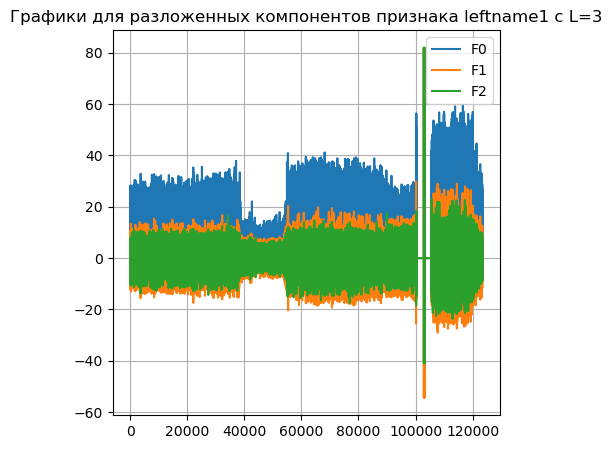

Проверка размера данных при L для контроля leftname1



(123407, 3)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака leftname1



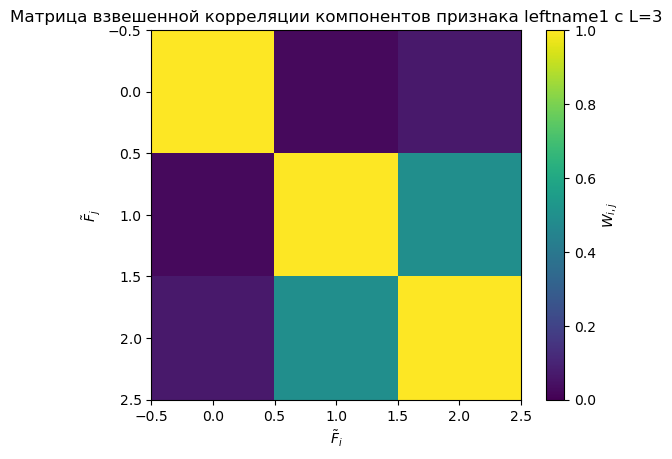

Ранжируем компоненты по убыванию важности признака leftname1

Визуализация первых 3х компонент признака leftname1



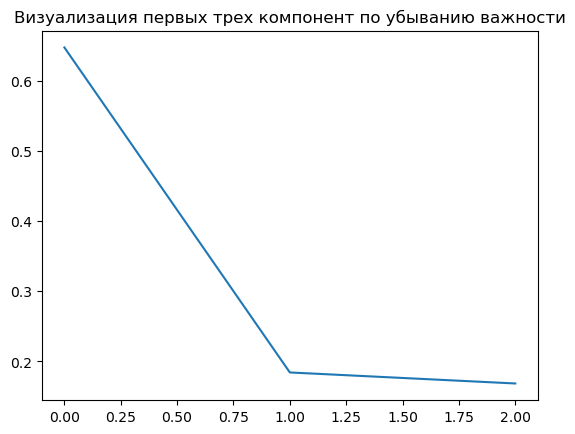

Показывает какое количество компонент объясняет основной процент информации



0.6478330229663654

0.16821457046321278

Показывает сколько компонент необходимо для заданного процента информации



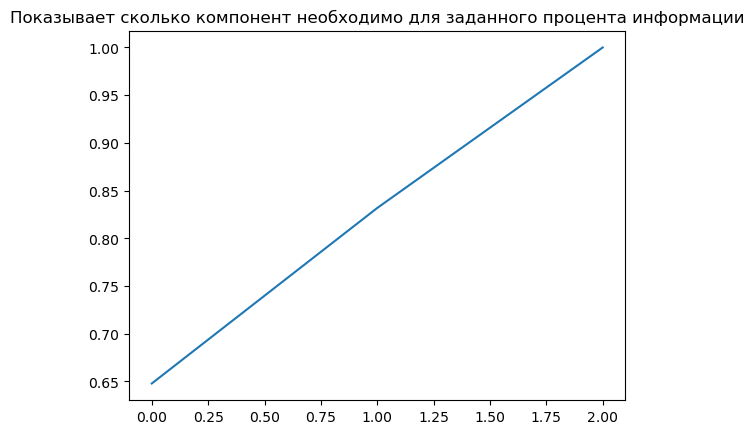

Реконструкция данных



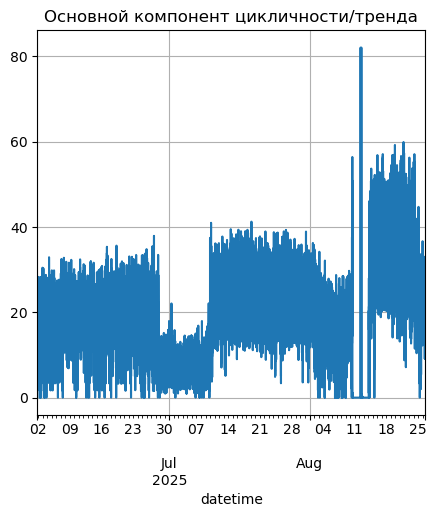

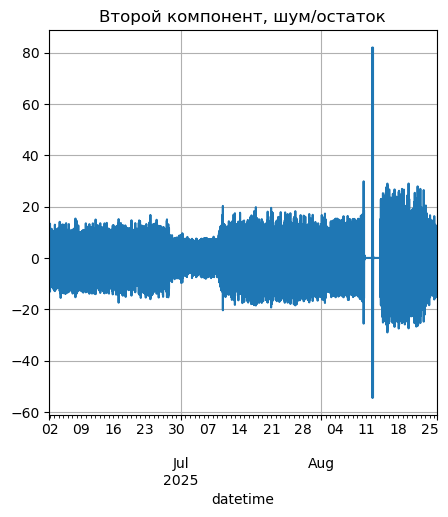

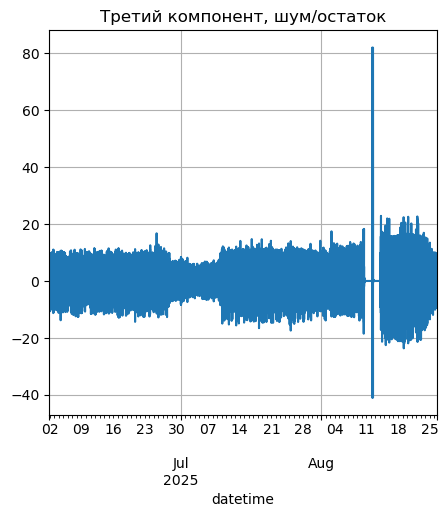

Разложение на компоненты признака leftname2



,F0,F1,F2
datetime,,,
2025-06-01 20:01:00,1.452784e-11,-6.224479e-12,-8.303362e-12
2025-06-01 20:02:00,5.951456e-12,5.611901e-12,1.921090e-12
2025-06-01 20:03:00,3.989918e-12,-1.222136e-12,2.767783e-12
2025-06-01 20:04:00,-8.560428e-13,-4.246824e-13,-1.280722e-12
2025-06-01 20:05:00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...
2025-08-26 12:43:00,-2.885099e-02,2.885099e-02,2.791465e-14
2025-08-26 12:44:00,-1.448212e-02,-7.184547e-03,2.166667e-02
2025-08-26 12:45:00,-1.448212e-02,-7.184547e-03,2.166667e-02


,F0,F1,F2
count,123407.000000,123407.000000,1.234070e+05
mean,0.370027,0.000001,-3.511413e-07
std,1.718978,0.658628,5.908495e-01
min,-0.202227,-54.638289,-4.104333e+01
25%,-0.050017,-0.010500,0.000000e+00
50%,-0.028851,0.000000,2.739017e-14
75%,0.000000,0.028851,2.166667e-02
max,81.985518,82.028851,8.202167e+01


Строим графики для разложенных компонентов признака leftname2



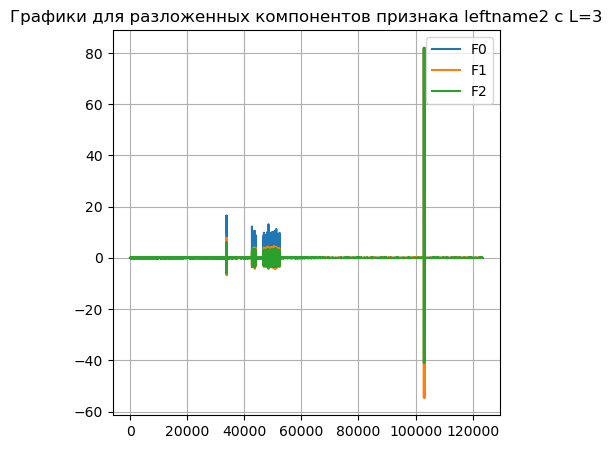

Проверка размера данных при L для контроля leftname2



(123407, 3)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака leftname2



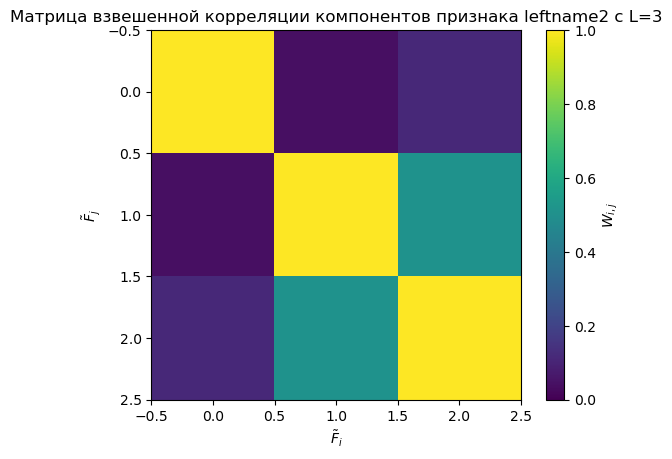

Ранжируем компоненты по убыванию важности признака leftname2

Визуализация первых 3х компонент признака leftname2



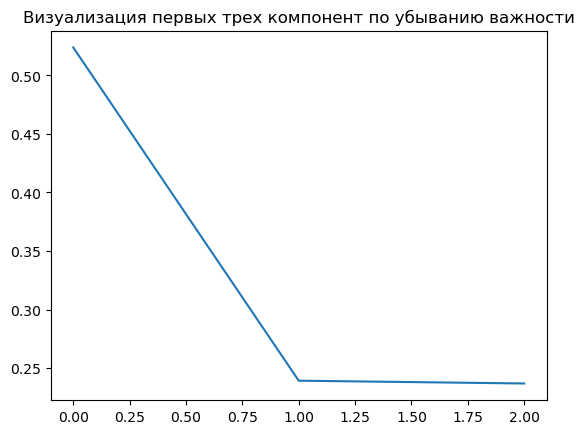

Показывает какое количество компонент объясняет основной процент информации



0.5237873394883381

0.23691731182463405

Показывает сколько компонент необходимо для заданного процента информации



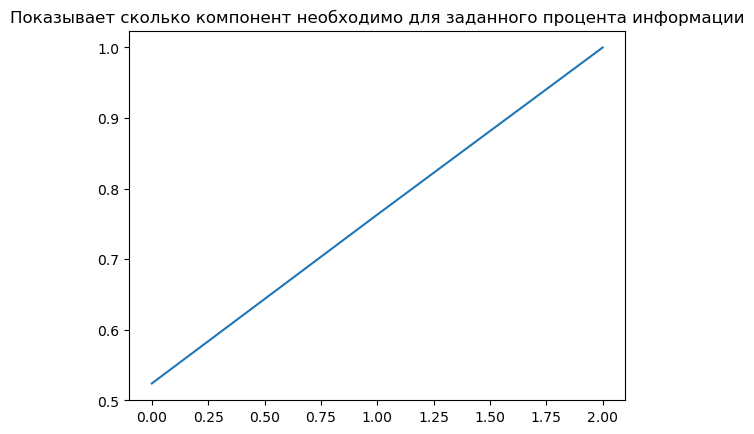

Реконструкция данных



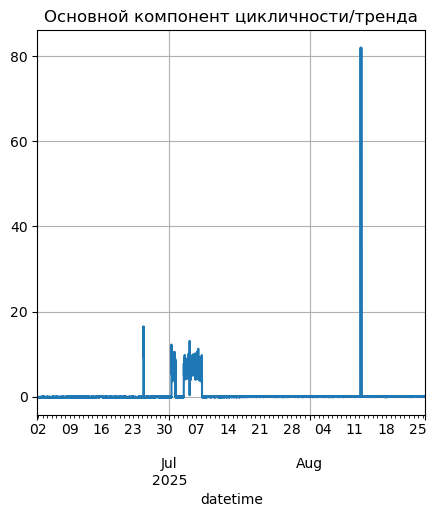

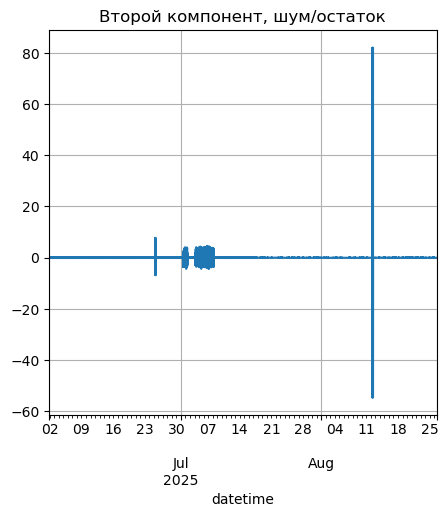

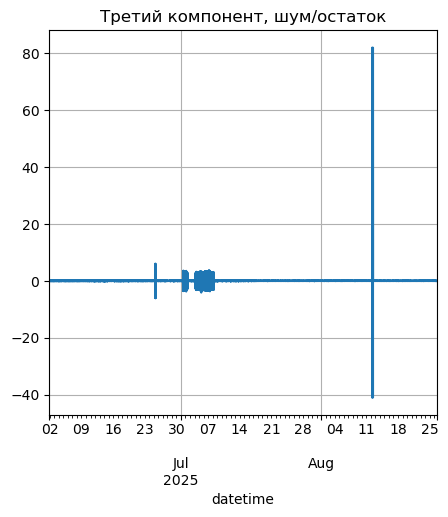

Разложение на компоненты признака rightname



,F0,F1,F2
datetime,,,
2025-06-01 20:01:00,-8.260034e-13,5.904303e-13,2.355731e-13
2025-06-01 20:02:00,-2.680303e-13,-5.222394e-13,-2.178196e-13
2025-06-01 20:03:00,-1.787707e-13,1.023034e-13,-7.750522e-14
2025-06-01 20:04:00,1.671161e+00,8.351533e-01,-2.506314e+00
2025-06-01 20:05:00,5.000527e+00,-2.512467e+00,-2.488060e+00
...,...,...,...
2025-08-26 12:43:00,1.667298e+01,-3.064973e-02,-5.567293e-01
2025-08-26 12:44:00,1.670295e+01,3.476691e-02,9.665785e-02
2025-08-26 12:45:00,1.501724e+01,-8.150967e-01,3.079582e+00


,F0,F1,F2
count,1.234070e+05,123407.000000,123407.000000
mean,1.096248e+01,-0.000008,-0.000047
std,8.725920e+00,3.368823,3.075354
min,-8.260034e-13,-19.554429,-11.845002
25%,0.000000e+00,-0.995770,-0.092917
50%,1.291113e+01,0.000000,0.000000
75%,1.697480e+01,1.209281,0.457648
max,3.598871e+01,23.293925,16.291802


Строим графики для разложенных компонентов признака rightname



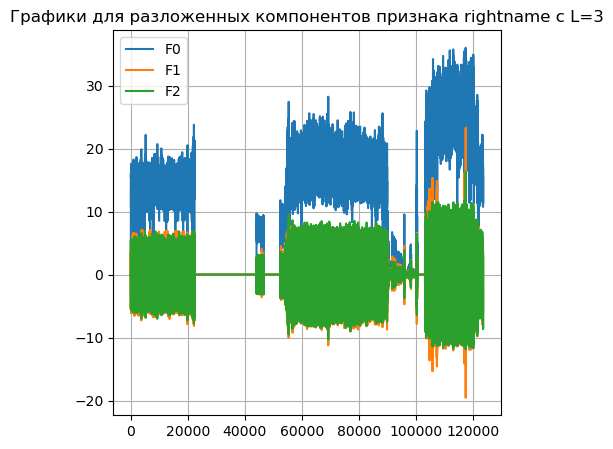

Проверка размера данных при L для контроля rightname



(123407, 3)

Смотрим матрицу взвешенной корреляции по компонентам для отражения связей между компонентами модели признака rightname



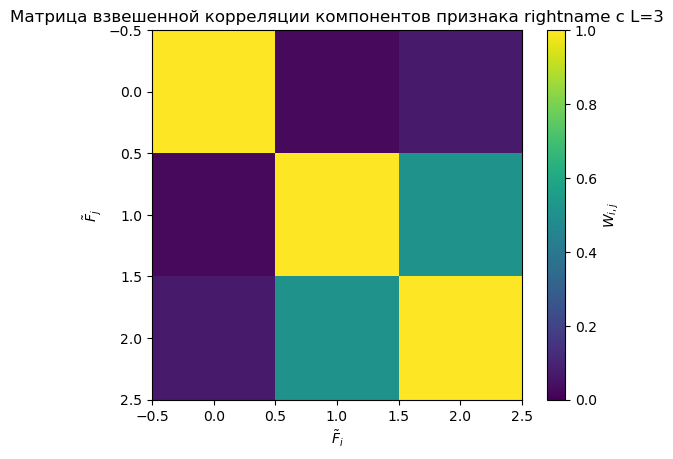

Ранжируем компоненты по убыванию важности признака rightname

Визуализация первых 3х компонент признака rightname



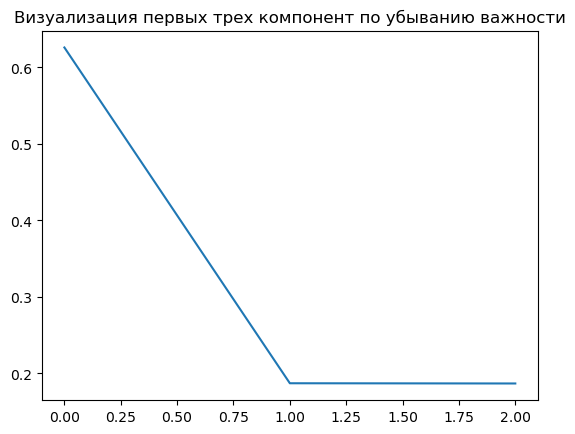

Показывает какое количество компонент объясняет основной процент информации



0.6260084153000222

0.18685110168702587

Показывает сколько компонент необходимо для заданного процента информации



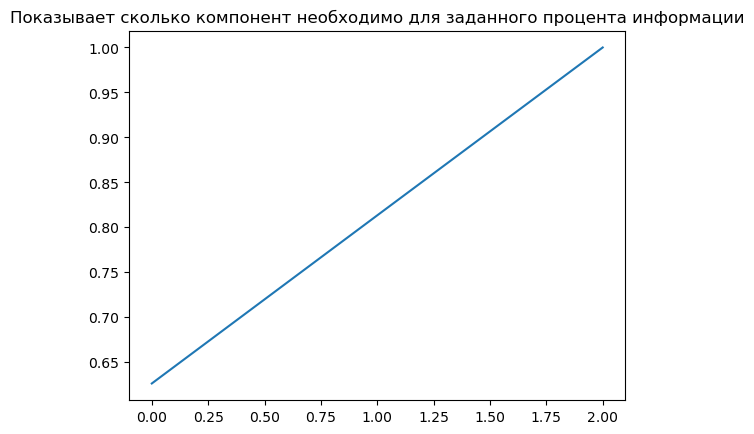

Реконструкция данных



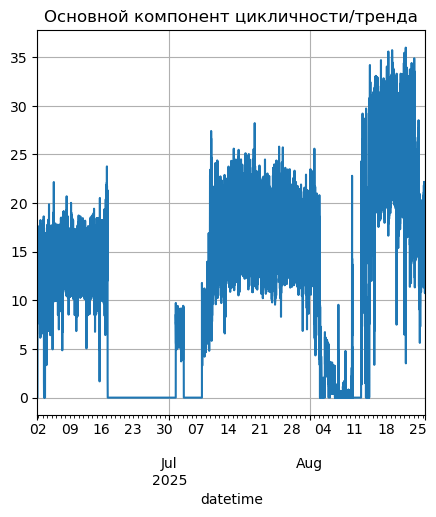

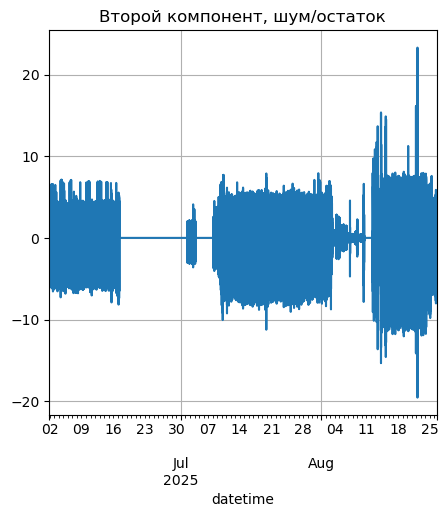

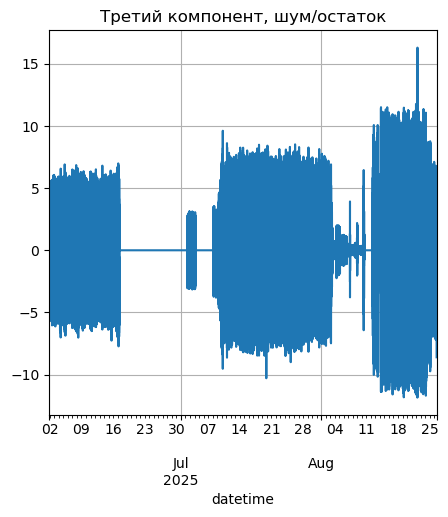

In [13]:
# исследуем признаки
research_signs(df['leftname1'], 3)
research_signs(df['leftname2'], 3)
research_signs(df['rightname'], 3)

Признак leftname1



,F0,F1,F2
datetime,,,
2025-06-01 20:01:00,1.116917e-11,-2.841553e-12,-8.327616e-12
2025-06-01 20:02:00,5.526087e-12,2.873194e-12,-2.308788e-15
2025-06-01 20:03:00,3.724095e-12,-9.481985e-13,2.775864e-12
2025-06-01 20:04:00,1.028006e-15,5.030027e-16,1.530999e-15
2025-06-01 20:05:00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...
2025-08-26 12:43:00,2.035927e+01,-3.959273e+00,-2.400000e-01
2025-08-26 12:44:00,2.231311e+01,5.740221e+00,5.066667e+00
2025-08-26 12:45:00,2.076764e+01,-3.994305e+00,-1.333333e-01


,F0,F1,F2
count,123407.000000,123407.000000,123407.000000
mean,19.490107,0.000507,-0.000006
std,9.623142,5.082502,4.041979
min,0.000000,-54.467176,-41.000000
25%,13.071932,-3.506710,-2.746667
50%,20.103474,0.000000,0.000000
75%,25.100905,2.309326,2.240000
max,82.000000,82.000000,82.000000


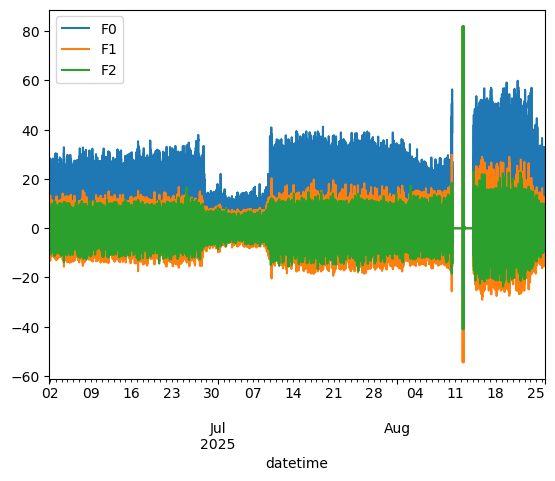

Признак leftname2



,F0,F1,F2
datetime,,,
2025-06-01 20:01:00,1.452784e-11,-6.224479e-12,-8.303362e-12
2025-06-01 20:02:00,5.951456e-12,5.611901e-12,1.921090e-12
2025-06-01 20:03:00,3.989918e-12,-1.222136e-12,2.767783e-12
2025-06-01 20:04:00,-8.560428e-13,-4.246824e-13,-1.280722e-12
2025-06-01 20:05:00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...
2025-08-26 12:43:00,-2.885099e-02,2.885099e-02,2.791465e-14
2025-08-26 12:44:00,-1.448212e-02,-7.184547e-03,2.166667e-02
2025-08-26 12:45:00,-1.448212e-02,-7.184547e-03,2.166667e-02


,F0,F1,F2
count,123407.000000,123407.000000,1.234070e+05
mean,0.370027,0.000001,-3.511413e-07
std,1.718978,0.658628,5.908495e-01
min,-0.202227,-54.638289,-4.104333e+01
25%,-0.050017,-0.010500,0.000000e+00
50%,-0.028851,0.000000,2.739017e-14
75%,0.000000,0.028851,2.166667e-02
max,81.985518,82.028851,8.202167e+01


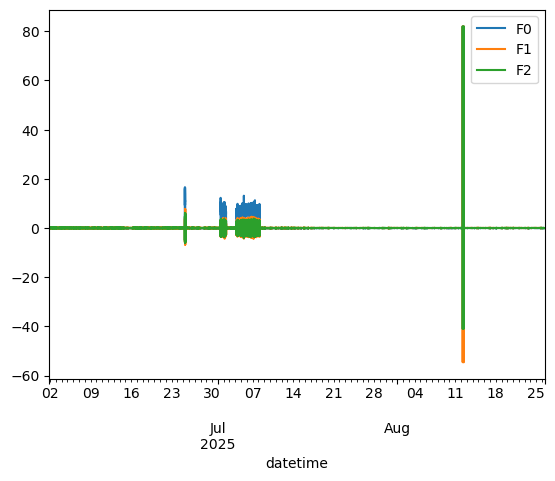

Признак rightname



,F0,F1,F2
datetime,,,
2025-06-01 20:01:00,-8.260034e-13,5.904303e-13,2.355731e-13
2025-06-01 20:02:00,-2.680303e-13,-5.222394e-13,-2.178196e-13
2025-06-01 20:03:00,-1.787707e-13,1.023034e-13,-7.750522e-14
2025-06-01 20:04:00,1.671161e+00,8.351533e-01,-2.506314e+00
2025-06-01 20:05:00,5.000527e+00,-2.512467e+00,-2.488060e+00
...,...,...,...
2025-08-26 12:43:00,1.667298e+01,-3.064973e-02,-5.567293e-01
2025-08-26 12:44:00,1.670295e+01,3.476691e-02,9.665785e-02
2025-08-26 12:45:00,1.501724e+01,-8.150967e-01,3.079582e+00


,F0,F1,F2
count,1.234070e+05,123407.000000,123407.000000
mean,1.096248e+01,-0.000008,-0.000047
std,8.725920e+00,3.368823,3.075354
min,-8.260034e-13,-19.554429,-11.845002
25%,0.000000e+00,-0.995770,-0.092917
50%,1.291113e+01,0.000000,0.000000
75%,1.697480e+01,1.209281,0.457648
max,3.598871e+01,23.293925,16.291802


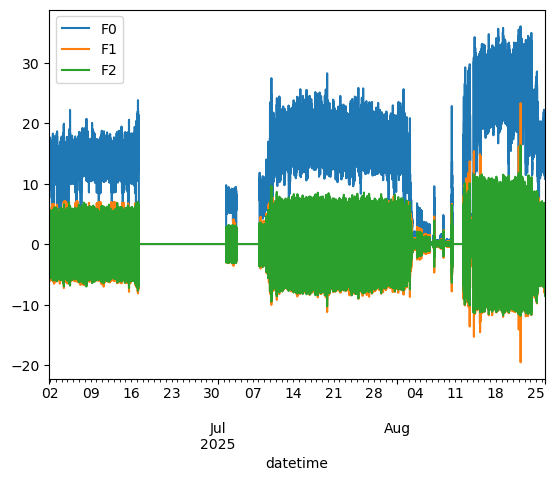

In [14]:
# Раскладываем на компоненты, выбираем рекомендуемый для тестирования и минимальных промежутков размер окна L
# Признак leftname1
print('Признак leftname1\n')
ssa_df_leftname1 = SSA(df['leftname1'], 3, save_mem=True)
components_df_leftname1 = ssa_df_leftname1.components_to_df()
display(components_df_leftname1)
display(components_df_leftname1.describe())
components_df_leftname1.plot()
plt.show()

# Признак leftname2
print('Признак leftname2\n')
ssa_df_leftname2 = SSA(df['leftname2'], 3, save_mem=True)
components_df_leftname2 = ssa_df_leftname2.components_to_df()
display(components_df_leftname2)
display(components_df_leftname2.describe())
components_df_leftname2.plot()
plt.show()

# Признак rightname
print('Признак rightname\n')
ssa_df_rightname = SSA(df['rightname'], 3, save_mem=True)
components_df_rightname = ssa_df_rightname.components_to_df()
display(components_df_rightname)
display(components_df_rightname.describe())
components_df_rightname.plot()
plt.show()

Первый признак leftname1

Угол наклона(+восходящий тренд/-нисходящий) тренд: 0.00008
Сдвиг(точка пересечения с осью Y): 14.47106
Коэффициент корреляции между x и y: 0.30113
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.00000
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



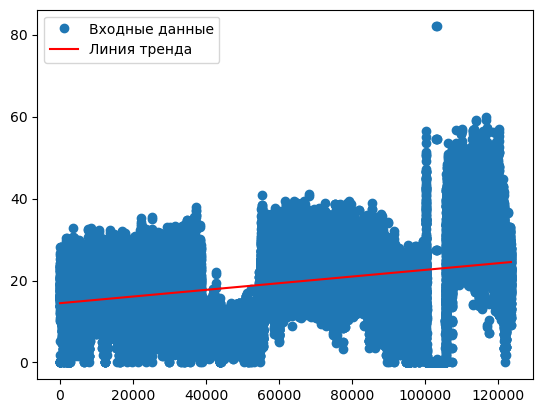

Второй признак leftname2

Угол наклона(+восходящий тренд/-нисходящий) тренд: -0.00000
Сдвиг(точка пересечения с осью Y): 0.59263
Коэффициент корреляции между x и y: -0.07477
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.00000
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



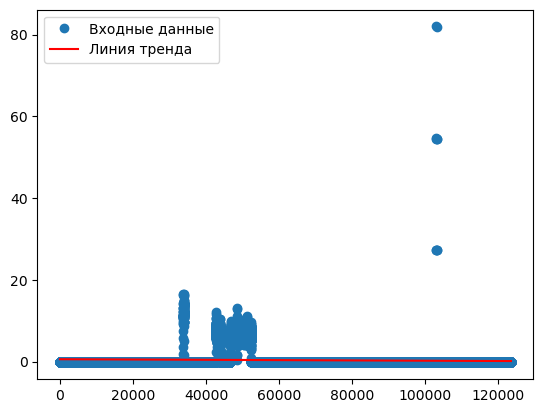

Третий признак rightname

Угол наклона(+восходящий тренд/-нисходящий) тренд: 0.00009
Сдвиг(точка пересечения с осью Y): 5.53966
Коэффициент корреляции между x и y: 0.35881
Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): 0.00000
Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): 0.00000



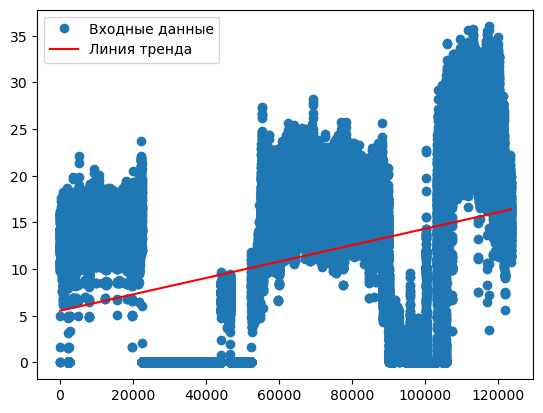

In [15]:
# Опредлим тренд линейной регрессией
# Первый признак
print('Первый признак leftname1\n')
x1 = np.arange(len(components_df_leftname1['F0']))
y1 = components_df_leftname1['F0'].values
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope1:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept1:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value1:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value1:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err1:.5f}\n')
plt.plot(x1, y1, 'o', label='Входные данные')
plt.plot(x1, intercept1 + slope1*x1, 'r', label='Линия тренда')
plt.legend()
plt.show()

# Второй признак
print('Второй признак leftname2\n')
x2 = np.arange(len(components_df_leftname2['F0']))
y2 = components_df_leftname2['F0'].values
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope2:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept2:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value2:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value2:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err2:.5f}\n')
plt.plot(x2, y2, 'o', label='Входные данные')
plt.plot(x2, intercept2 + slope2*x2, 'r', label='Линия тренда')
plt.legend()
plt.show()

# Третий признак
print('Третий признак rightname\n')
x3 = np.arange(len(components_df_rightname['F0']))
y3 = components_df_rightname['F0'].values
slope3, intercept3, r_value3, p_value3, std_err3 = linregress(x3, y3)
print(f'Угол наклона(+восходящий тренд/-нисходящий) тренд: {slope3:.5f}')
print(f'Сдвиг(точка пересечения с осью Y): {intercept3:.5f}')
print(f'Коэффициент корреляции между x и y: {r_value3:.5f}')
print(f'Статистическая значимость наклона(Н0 - нет тренда, если p-value < 0.05, то тренд существует): {p_value3:.5f}')
print(f'Стандартная ошибка наклона(чем меньше, тем точнее оценка тренда): {std_err3:.5f}\n')
plt.plot(x3, y3, 'o', label='Входные данные')
plt.plot(x3, intercept3 + slope3*x3, 'r', label='Линия тренда')
plt.legend()
plt.show()

По итогам анализа трендов делаем вывод - тренды по основным компонентам 3х признаков есть.

In [16]:
# склеиваем основные компоненты признаков в один датафрейм
main_df_ssa = pd.DataFrame({'leftname1_F0': components_df_leftname1['F0'],
                             'leftname2_F0': components_df_leftname2['F0'],
                             'rightname_F0': components_df_rightname['F0']})
display(main_df_ssa.head(10))

,leftname1_F0,leftname2_F0,rightname_F0
datetime,,,
2025-06-01 20:01:00,1.116917e-11,1.452784e-11,-8.260034e-13
2025-06-01 20:02:00,5.526087e-12,5.951456e-12,-2.680303e-13
2025-06-01 20:03:00,3.724095e-12,3.989918e-12,-1.787707e-13
2025-06-01 20:04:00,1.028006e-15,-8.560428e-13,1.671161e+00
2025-06-01 20:05:00,0.000000e+00,0.000000e+00,5.000527e+00
2025-06-01 20:06:00,0.000000e+00,0.000000e+00,1.006297e+01
2025-06-01 20:07:00,0.000000e+00,0.000000e+00,1.178307e+01
2025-06-01 20:08:00,0.000000e+00,0.000000e+00,1.185068e+01
2025-06-01 20:09:00,0.000000e+00,0.000000e+00,1.027009e+01


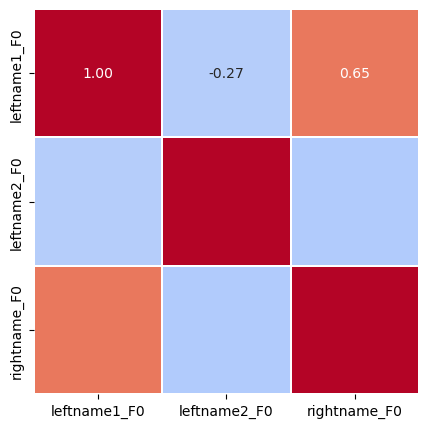

,leftname1_F0,leftname2_F0,rightname_F0
leftname1_F0,1.000000,-0.266076,0.654093
leftname2_F0,-0.266076,1.000000,-0.291711
rightname_F0,0.654093,-0.291711,1.000000


In [17]:
# Построим матрицу, выведем значения корреляций
plt.figure(figsize=(5,5))
sns.heatmap(main_df_ssa.corr(), vmin=-1, vmax=1, annot=True, square=True, cbar=False, linewidth=0.1, cmap='coolwarm', fmt='.2f')
plt.show()
display(main_df_ssa.corr())

По матрице корреляций следует отметить, что присутствует слабая обратная корреляция -0,27 между левым вторым признаком и левым первым признаком, корреляция между левым первым признаком и правым признаком достаточно сильная прямая 0,65, между левым вторым и правым признаком корреляция слабая обратная -0,29.

Признак leftname1



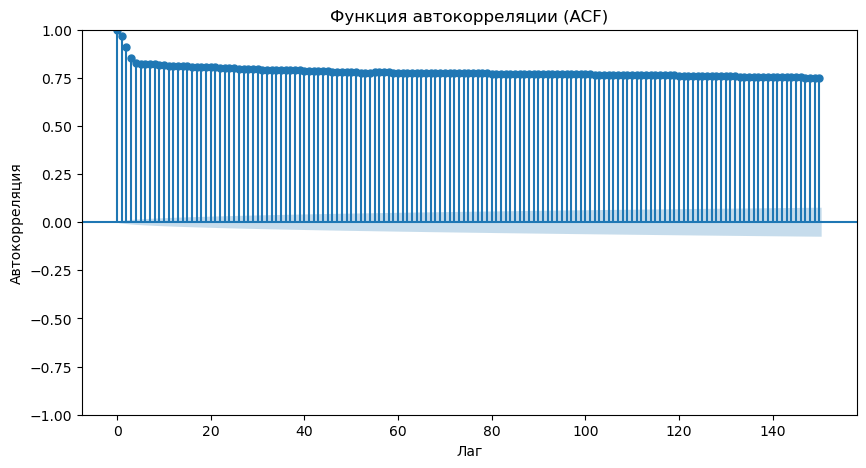

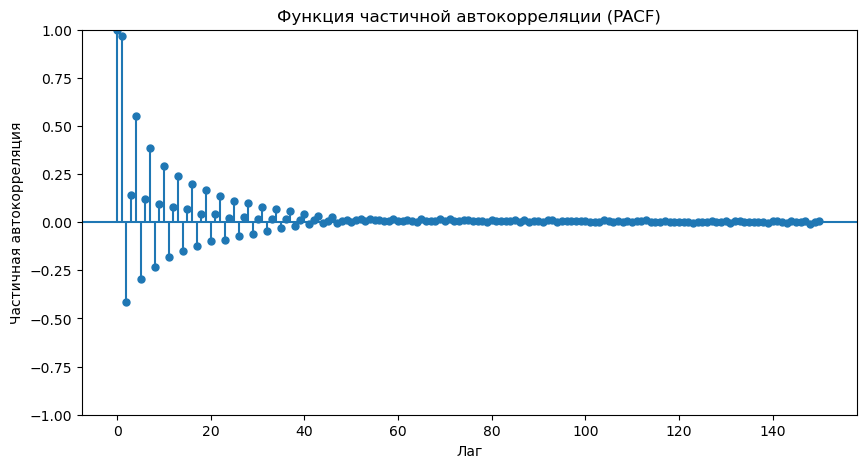

Признак leftname2



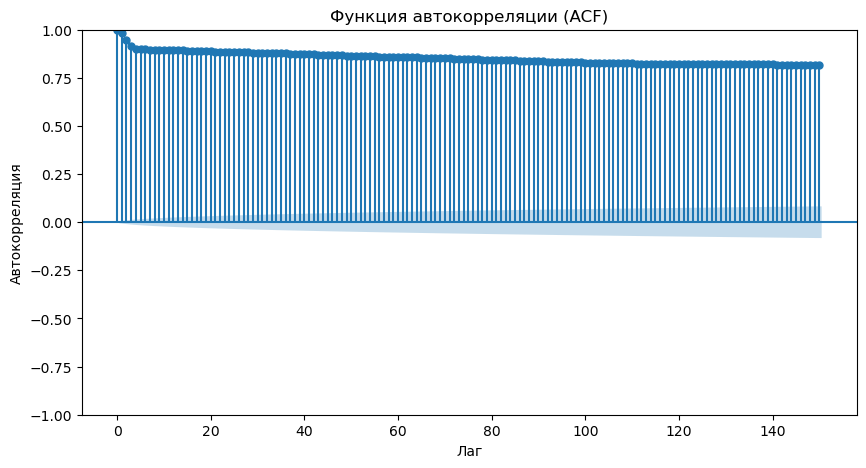

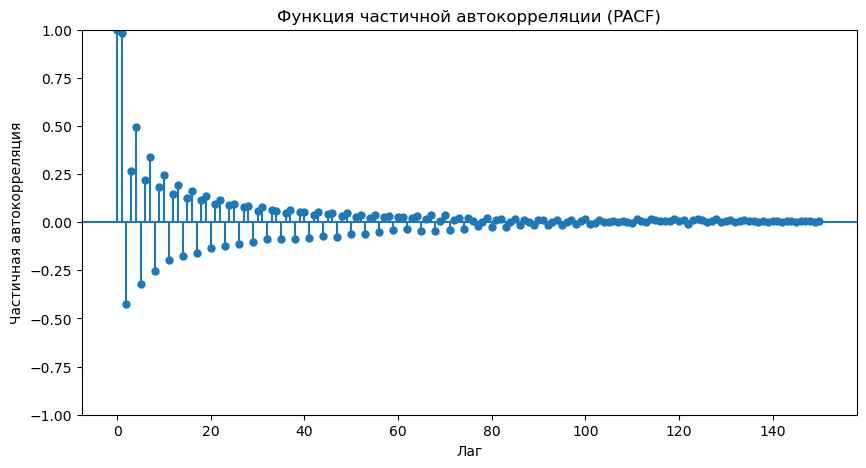

Признак rightname



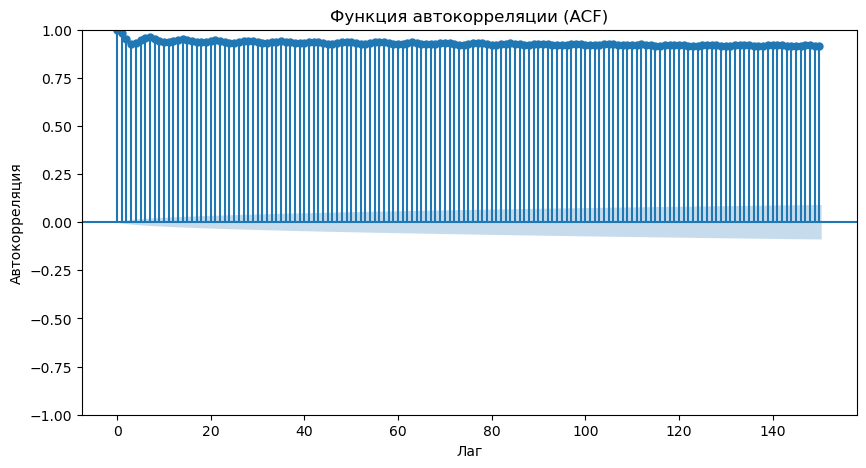

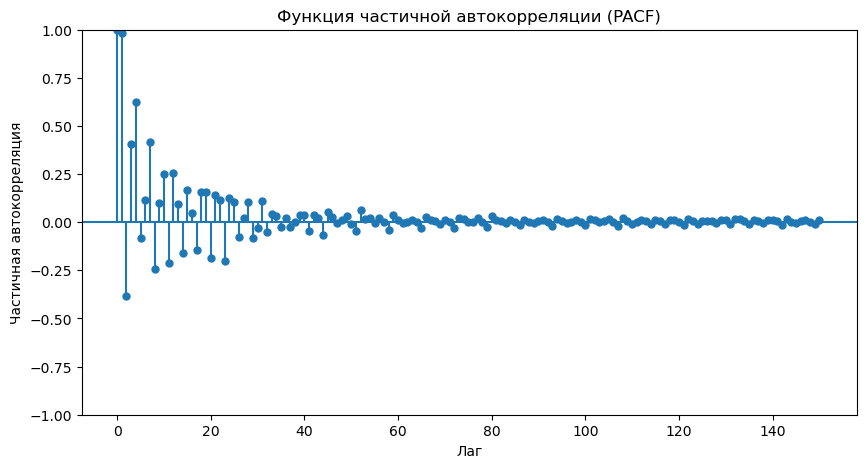

In [18]:
# проведем автокорреляционный анализ основных компоненнтов признаков
# Признак leftname1
print('Признак leftname1\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_leftname1['F0'], lags=150, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_leftname1['F0'], lags=150, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

# Признак leftname2
print('Признак leftname2\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_leftname2['F0'], lags=150, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_leftname2['F0'], lags=150, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

# Признак rightname
print('Признак rightname\n')
# ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(components_df_rightname['F0'], lags=150, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Автокорреляция')
ax.set_title('Функция автокорреляции (ACF)')
plt.show
# PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(components_df_rightname['F0'], lags=150, ax=ax)
ax.set_xlabel('Лаг')
ax.set_ylabel('Частичная автокорреляция')
ax.set_title('Функция частичной автокорреляции (PACF)')
plt.show()

По графикам автокорреляции и частичной автокорреляции можно подтвердить вывод, что тренды есть.

,leftname1_F0,leftname2_F0,rightname_F0,left_result_F0
datetime,,,,
2025-06-01 20:01:00,1.116917e-11,1.452784e-11,-8.260034e-13,-3.358673e-12
2025-06-01 20:02:00,5.526087e-12,5.951456e-12,-2.680303e-13,-4.253693e-13
2025-06-01 20:03:00,3.724095e-12,3.989918e-12,-1.787707e-13,-2.658228e-13
2025-06-01 20:04:00,1.028006e-15,-8.560428e-13,1.671161e+00,8.570708e-13
2025-06-01 20:05:00,0.000000e+00,0.000000e+00,5.000527e+00,0.000000e+00
2025-06-01 20:06:00,0.000000e+00,0.000000e+00,1.006297e+01,0.000000e+00
2025-06-01 20:07:00,0.000000e+00,0.000000e+00,1.178307e+01,0.000000e+00
2025-06-01 20:08:00,0.000000e+00,0.000000e+00,1.185068e+01,0.000000e+00
2025-06-01 20:09:00,0.000000e+00,0.000000e+00,1.027009e+01,0.000000e+00


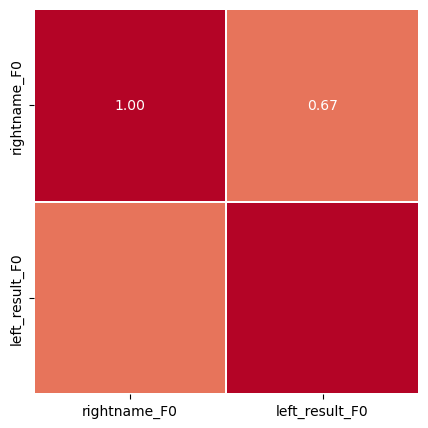

,rightname_F0,left_result_F0
rightname_F0,1.000000,0.665231
left_result_F0,0.665231,1.000000


In [19]:
# расчет корреляции между левой и правой частью при разных сдвигах
# нулевой сдвиг
main_df_ssa_base_lag = main_df_ssa.copy()
main_df_ssa_base_lag['left_result_F0'] = main_df_ssa_base_lag['leftname1_F0'] - main_df_ssa_base_lag['leftname2_F0']
display(main_df_ssa_base_lag.head(10))
# считаем корреляцию при нулевом сдвиге
# построим матрицу, выведем значения корреляций
main_df_ssa_base_lag = main_df_ssa_base_lag.drop(columns=['leftname1_F0', 'leftname2_F0'])
plt.figure(figsize=(5,5))
sns.heatmap(main_df_ssa_base_lag.corr(), vmin=-1, vmax=1, annot=True, square=True, cbar=False, linewidth=0.1, cmap='coolwarm', fmt='.2f')
plt.show()
display(main_df_ssa_base_lag.corr())

In [20]:
main_df_ssa.head(10)

,leftname1_F0,leftname2_F0,rightname_F0
datetime,,,
2025-06-01 20:01:00,1.116917e-11,1.452784e-11,-8.260034e-13
2025-06-01 20:02:00,5.526087e-12,5.951456e-12,-2.680303e-13
2025-06-01 20:03:00,3.724095e-12,3.989918e-12,-1.787707e-13
2025-06-01 20:04:00,1.028006e-15,-8.560428e-13,1.671161e+00
2025-06-01 20:05:00,0.000000e+00,0.000000e+00,5.000527e+00
2025-06-01 20:06:00,0.000000e+00,0.000000e+00,1.006297e+01
2025-06-01 20:07:00,0.000000e+00,0.000000e+00,1.178307e+01
2025-06-01 20:08:00,0.000000e+00,0.000000e+00,1.185068e+01
2025-06-01 20:09:00,0.000000e+00,0.000000e+00,1.027009e+01


Корреляция между левыми признаками и правым признаком достаточно сильная прямая 0,67, при условии описанной физики процесса.

Лаг 0, корреляция 0.6652314097874258
Лаг 1, корреляция 0.6645488243091175
Лаг 2, корреляция 0.662919376290577
Лаг 3, корреляция 0.6612118324670615
Лаг 4, корреляция 0.6599230691227469
Лаг 5, корреляция 0.6591272363782541
Лаг 6, корреляция 0.6584994045030657
Лаг 7, корреляция 0.6580607831683482
Лаг 8, корреляция 0.6574869837227115
Лаг 9, корреляция 0.6567024387164969
Лаг 10, корреляция 0.6556442908906526
Лаг 11, корреляция 0.654724589382959
Лаг 12, корреляция 0.6543160018736022
Лаг 13, корреляция 0.654360330670838
Лаг 14, корреляция 0.6545435789016633
Лаг 15, корреляция 0.6544149053638869
Лаг 16, корреляция 0.6539742288158481
Лаг 17, корреляция 0.6533096601142133
Лаг 18, корреляция 0.6527527595128765
Лаг 19, корреляция 0.6524097845955277
Лаг 20, корреляция 0.6523007476014383
Лаг 21, корреляция 0.6521865991424284
Лаг 22, корреляция 0.651952744324104
Лаг 23, корреляция 0.6515134492910452
Лаг 24, корреляция 0.6511006803350383
Лаг 25, корреляция 0.6508146998407943
Лаг 26, корреляция 0.65078

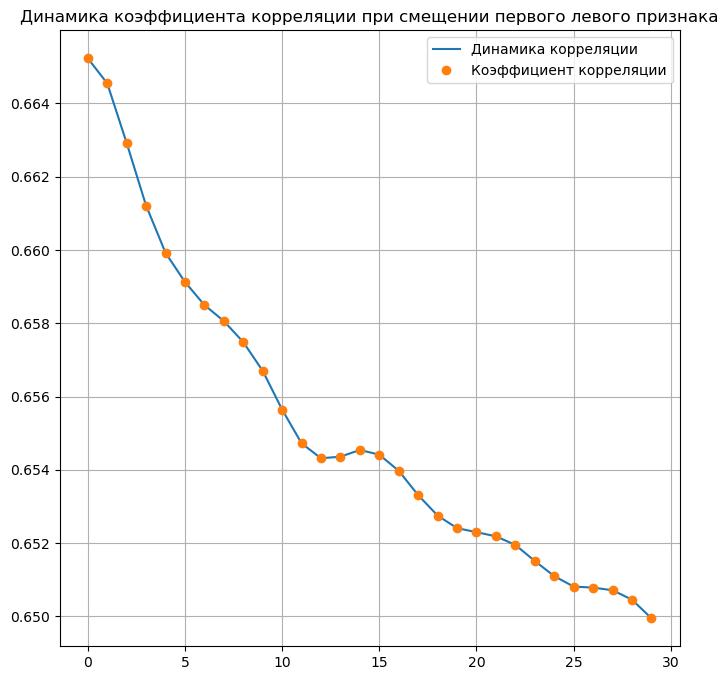

In [21]:
# динамика коэффициента корреляции при смещении первого левого признака
coeff_corr_array_1 = []
# задан максимальный лаг в 30 единиц, методом перебора  
lag = 1
max_lag = 30
for i in range(max_lag):
    data = main_df_ssa.copy()
    data['leftname1_F0'] = data['leftname1_F0'].shift(i, axis=0)
    data = data.dropna()
    data['left_result_F0'] = data['leftname1_F0'] - data['leftname2_F0']
    data = data.drop(columns=['leftname1_F0', 'leftname2_F0'])
    coeff_corr_array_1.append(np.corrcoef(data['rightname_F0'], data['left_result_F0'])[0, 1])
    print(f'Лаг {i}, корреляция {coeff_corr_array_1[i]}')

pd.DataFrame(data=coeff_corr_array_1, columns=['Динамика корреляции']).plot(grid=True, figsize=(8,8)).plot()
plt.plot(pd.DataFrame(data=coeff_corr_array_1, columns=['Динамика корреляции']), 'o', label='Коэффициент корреляции')
plt.legend()
plt.title('Динамика коэффициента корреляции при смещении первого левого признака')
plt.show()

Лаг 0, корреляция 0.6652314097874258
Лаг 1, корреляция 0.6649962134125824
Лаг 2, корреляция 0.6645251961794737
Лаг 3, корреляция 0.6640350320106123
Лаг 4, корреляция 0.6637855549150418
Лаг 5, корреляция 0.6636970060171835
Лаг 6, корреляция 0.6637029732957989
Лаг 7, корреляция 0.663705781003324
Лаг 8, корреляция 0.6636977948684735
Лаг 9, корреляция 0.6636754623389874
Лаг 10, корреляция 0.6636482754597187
Лаг 11, корреляция 0.663625423874135
Лаг 12, корреляция 0.6636111399419001
Лаг 13, корреляция 0.6636136849851463
Лаг 14, корреляция 0.6636337169852453
Лаг 15, корреляция 0.6636588092513948
Лаг 16, корреляция 0.6636745330411344
Лаг 17, корреляция 0.6636682286884769
Лаг 18, корреляция 0.6636559258523924
Лаг 19, корреляция 0.6636382261790308
Лаг 20, корреляция 0.6636230384240925
Лаг 21, корреляция 0.6635981719400135
Лаг 22, корреляция 0.6635682608899147
Лаг 23, корреляция 0.6635366265493448
Лаг 24, корреляция 0.663508039054329
Лаг 25, корреляция 0.6634911370488565
Лаг 26, корреляция 0.6634

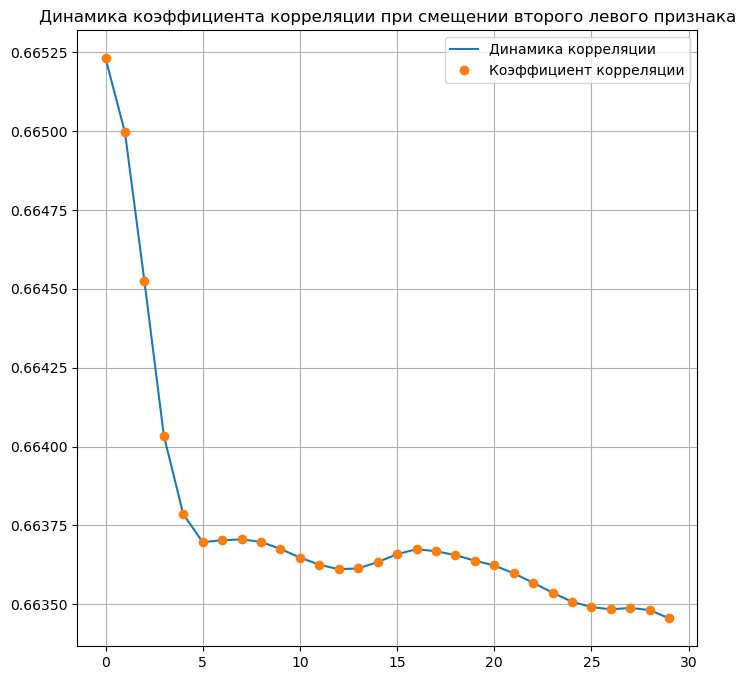

In [22]:
# динамика коэффициента корреляции при смещении второго левого признака
coeff_corr_array_2 = []
# задан максимальный лаг в 30 единиц, методом перебора
lag = 1
max_lag = 30
for i in range(max_lag):
    data = main_df_ssa.copy()
    data['leftname2_F0'] = data['leftname2_F0'].shift(i, axis=0)
    data = data.dropna()
    data['left_result_F0'] = data['leftname1_F0'] - data['leftname2_F0']
    data = data.drop(columns=['leftname1_F0', 'leftname2_F0'])
    coeff_corr_array_2.append(np.corrcoef(data['rightname_F0'], data['left_result_F0'])[0, 1])
    print(f'Лаг {i}, корреляция {coeff_corr_array_2[i]}')

pd.DataFrame(data=coeff_corr_array_2, columns=['Динамика корреляции']).plot(grid=True, figsize=(8,8)).plot()
plt.plot(pd.DataFrame(data=coeff_corr_array_2, columns=['Динамика корреляции']), 'o', label='Коэффициент корреляции')
plt.legend()
plt.title('Динамика коэффициента корреляции при смещении второго левого признака')
plt.show()

Лаг 0, корреляция 0.6652314097874258
Лаг 1, корреляция 0.6645896827142416
Лаг 2, корреляция 0.6633539084654073
Лаг 3, корреляция 0.6621237660398464
Лаг 4, корреляция 0.6615076951368553
Лаг 5, корреляция 0.6611151274064576
Лаг 6, корреляция 0.6607466032989859
Лаг 7, корреляция 0.6601270332828906
Лаг 8, корреляция 0.6594884523417115
Лаг 9, корреляция 0.65884003573578
Лаг 10, корреляция 0.6582324304262416
Лаг 11, корреляция 0.6576784007717758
Лаг 12, корреляция 0.6572640760503712
Лаг 13, корреляция 0.6568525129880457
Лаг 14, корреляция 0.6563543582693916
Лаг 15, корреляция 0.6556854515071416
Лаг 16, корреляция 0.6551919716048545
Лаг 17, корреляция 0.6549214635786313
Лаг 18, корреляция 0.6548591364515578
Лаг 19, корреляция 0.654648272390879
Лаг 20, корреляция 0.6542751175292448
Лаг 21, корреляция 0.6537615951577177
Лаг 22, корреляция 0.6532888081678955
Лаг 23, корреляция 0.6529537086387696
Лаг 24, корреляция 0.6528219547025261
Лаг 25, корреляция 0.6528303066016996
Лаг 26, корреляция 0.6527

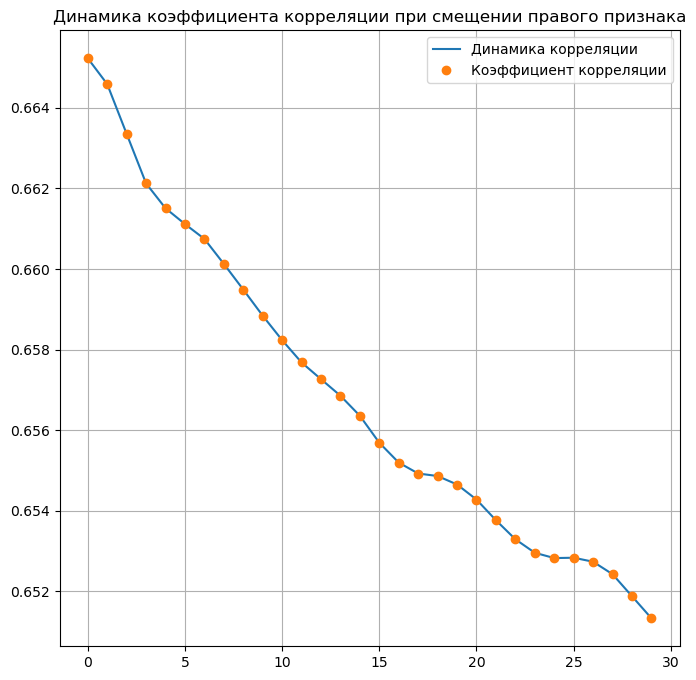

In [23]:
# динамика коэффициента корреляции при смещении правого признака
coeff_corr_array_3 = []
# задан максимальный лаг в 30 единиц, методом перебора
lag = 1
max_lag = 30
for i in range(max_lag):
    data = main_df_ssa.copy()
    data['rightname_F0'] = data['rightname_F0'].shift(i, axis=0)
    data = data.dropna()
    data['left_result_F0'] = data['leftname1_F0'] - data['leftname2_F0']
    data = data.drop(columns=['leftname1_F0', 'leftname2_F0'])
    coeff_corr_array_3.append(np.corrcoef(data['rightname_F0'], data['left_result_F0'])[0, 1])
    print(f'Лаг {i}, корреляция {coeff_corr_array_3[i]}')

pd.DataFrame(data=coeff_corr_array_3, columns=['Динамика корреляции']).plot(grid=True, figsize=(8,8)).plot()
plt.plot(pd.DataFrame(data=coeff_corr_array_3, columns=['Динамика корреляции']), 'o', label='Коэффициент корреляции')
plt.legend()
plt.title('Динамика коэффициента корреляции при смещении правого признака')
plt.show()

### Вывод
В ходе задачи было необходимо определить экспертно наилучший лаг, при котором коэффициент корреляции между разницей столбцов(левый первый и левый второй) и между правым столбцом был бы приближен к масимально возможному.

Были обработаны и проанализированы входные данные признаков на предмет наличия дублей и пропусков данных, индекс был сформирован на основании столбца datetime.

Коэффициент корреляции неочищенных данных левых и правого признака составил 0,41, было предпринято разделение данных на трендовые и остаточные части путем применения SSA, по итогам чего было вяснено, что левый первый признак имеет наибольшую корреляцию с правым и составляет 0,65, а при подсчете разницы признаков - левые признаки имеют сильную корреляцию с правым, эта корреляция составила 0,67.

Далее были проанализированы лаги в 3х сценариях:
1. смещение левого первого признака от 1 до 30 единиц,
2. смещение левого второго признака от 1 до 30 единиц,
3. смещение правого признака от 1 до 30 единиц.

По итогам анализа смещений в рамках заданных лагов были получены данные корреляций признаков между собой и стало возможным сделать вывод, что при росте величины лага - корреляция между показателями имеет линейный характер снижения.
